## PART 1: Theory

## Linear Regression — Complete Beginner Lesson

This lesson is designed for absolute beginners in data analysis / data science. It is structured so that it can be taught over multiple sessions (lectures + labs), with clear explanations, intuitive examples, and a large hands-on project at the end.

### Lesson Structure

- Introduction to Linear Regression

- Assumptions of Linear Regression

- Types of Linear Regression

- Model Training & Prediction Process

- Model Evaluation Metrics

- Common Pitfalls & Mistakes





### What is Linear Regression?

Linear Regression is a **supervised machine learning** algorithm used to:

- Predict a numerical (continuous) value

- Understand the relationship between variables

**Example questions linear regression can answer:**

- How does study time affect exam scores?

- How does advertising spend affect sales?

- How does house size affect house price?

At its core, linear regression fits a straight line through data points.

### Real-World Intuition

Imagine plotting:

- X-axis → Hours studied

- Y-axis → Exam marks

**You will likely notice:**

- As hours studied increase, marks increase

- Linear regression finds the best possible straight line that represents this relationship.

🎯 Goal:

- Use the line to predict future outcomes and quantify relationships.

### Simple Linear Regression

Simple Linear Regression uses one input feature.

📐 Equation

    𝑦 = 𝑚𝑥 + 𝑏

Where:

y = predicted value (target)

x = input feature

m = slope (how much y changes when x increases by 1)

b = intercept (value of y when x = 0)

📊 Example:

For every extra hour studied, marks increase by 5 points.

### Assumptions of Linear Regression

- Linear regression works best when these assumptions hold:



**Linearity** : relationship is linear

    A change in an input variable causes a proportional and consistent change in the output.

    👉 When you plot the data, the pattern can be well described by a straight line.

    We can identify this using pearson correlation

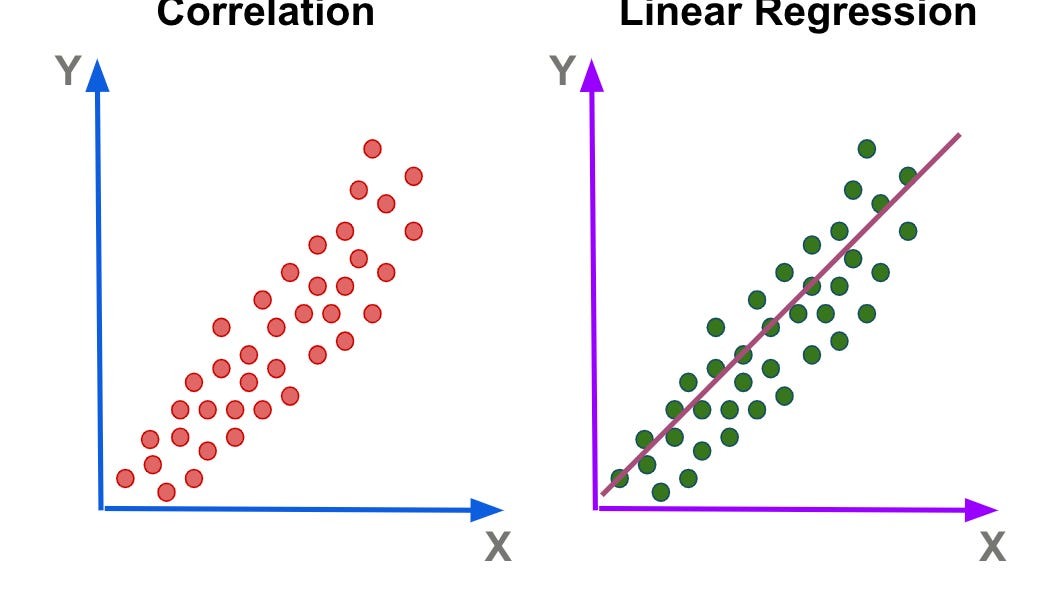

In [ ]:
from IPython.display import Image, display
display(Image(filename="Correlation.jpg"))

### Independence – observations are independent

What it means

- Each data point should not influence another.

- One observation should not depend on a previous or nearby one.

- Errors (residuals) should not be correlated.

### Homoscedasticity – constant variance of errors

**What it means**

- The spread of residuals (errors) should be roughly the same at all values of X.

- In simple terms:

    The model should be equally wrong across all predictions.


The spread of residuals refers to how wide or narrow the errors are.


If the residuals:

- Stay equally scattered everywhere → good

- Become more scattered in some regions → problem

### Normality of errors
What it means

    The residuals (errors) should follow a normal (bell-shaped) distribution.

Important:

    The errors, not the predictors or target variable, must be normal.

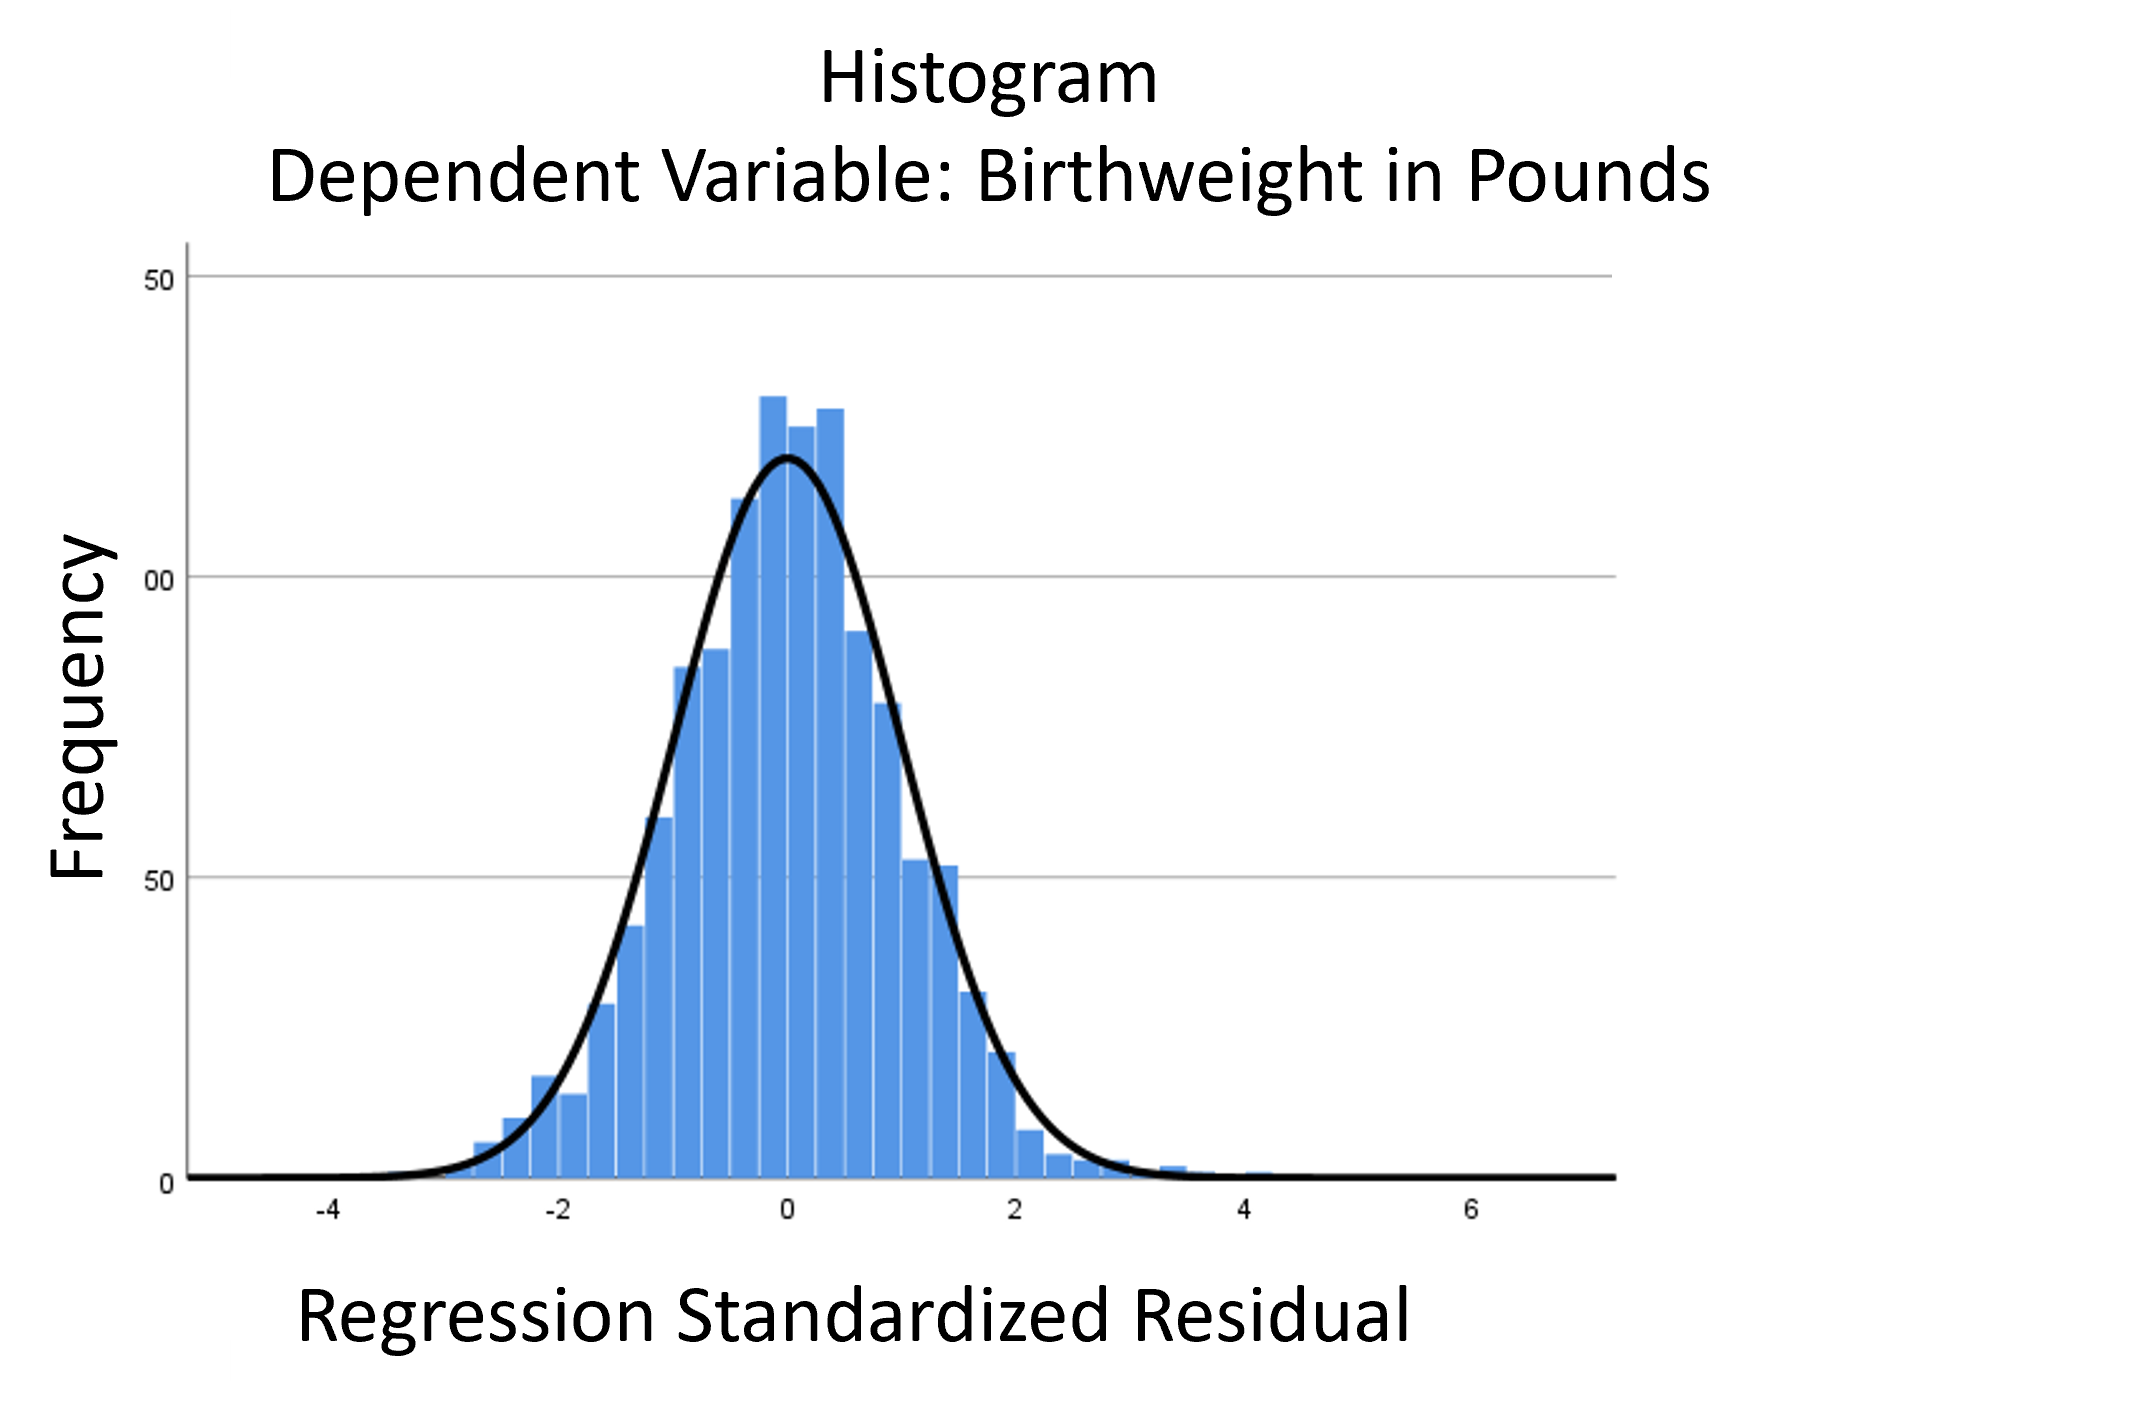

In [ ]:
display(Image(filename="Residuals.png"))

### Evaluation Metrics
    
**R-squared (R²)**
- Measures how much variance is explained
- Ranges from 0 to 1

**MAE (Mean Absolute Error)**
- Average absolute error

**MSE / RMSE**
- Penalizes large errors more heavily
- MSE more than RMSE
  **RMSE**
      more convinient, directly comparable to the original data scale

## PART 2: PRACTICAL CODE (STEP-BY-STEP)

### Dataset details

**File name:** student_performance.csv
**Number of rows:** 150

Columns:

- hours_studied (1–9 hours)

- attendance_percentage (50–100%)

- previous_test_score (40–90)

- sleep_hours (4–8 hours)

- final_exam_score (numerical target, with realistic noise)



### Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load the Dataset

In [9]:
df = pd.read_csv("student_performance.csv")
df.head()

,hours_studied,attendance_percentage,previous_test_score,sleep_hours,final_exam_score
0,7,61,67,5,74.0
1,4,88,69,5,87.0
2,8,51,68,8,89.0
3,5,52,85,7,83.0
4,7,98,45,5,83.0


### Understand the Data

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hours_studied          150 non-null    int64  
 1   attendance_percentage  150 non-null    int64  
 2   previous_test_score    150 non-null    int64  
 3   sleep_hours            150 non-null    int64  
 4   final_exam_score       150 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 6.0 KB


,hours_studied,attendance_percentage,previous_test_score,sleep_hours,final_exam_score
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.300000,74.293333,66.253333,6.046667,81.893333
std,2.633675,14.659695,13.953993,1.457849,14.471516
min,1.000000,50.000000,40.000000,4.000000,44.000000
25%,3.000000,61.500000,55.250000,5.000000,72.000000
50%,5.000000,75.000000,67.000000,6.000000,82.500000
75%,8.000000,85.000000,78.000000,7.000000,94.750000
max,9.000000,99.000000,89.000000,8.000000,108.000000


Check missing values:

In [11]:
df.isnull().sum()

,0
hours_studied,0
attendance_percentage,0
previous_test_score,0
sleep_hours,0
final_exam_score,0


### Exploratory Data Analysis (EDA)

#### Scatter Plots

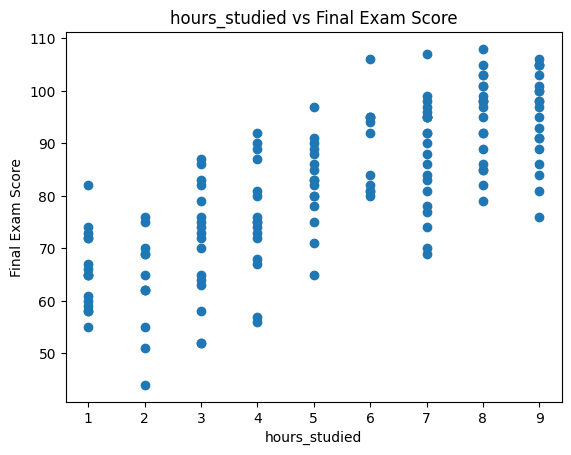

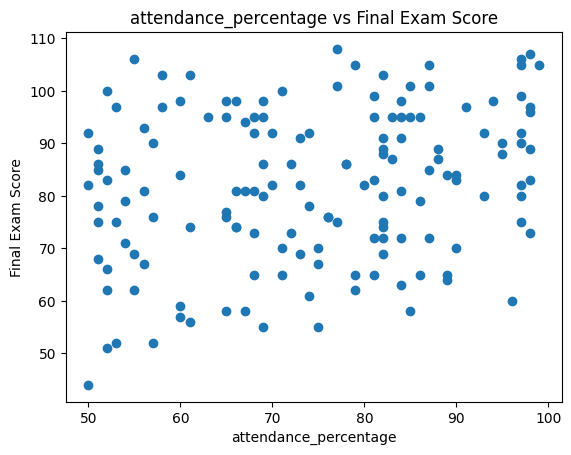

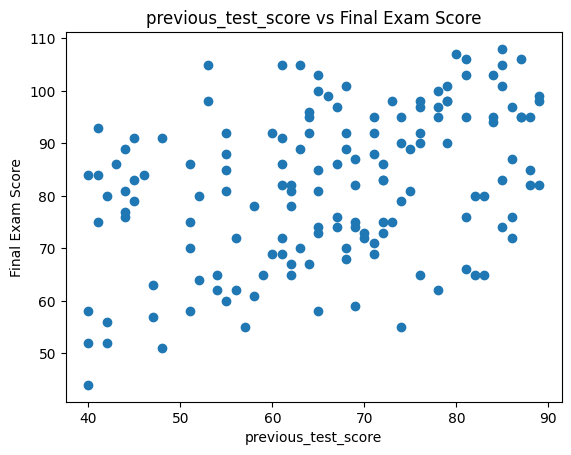

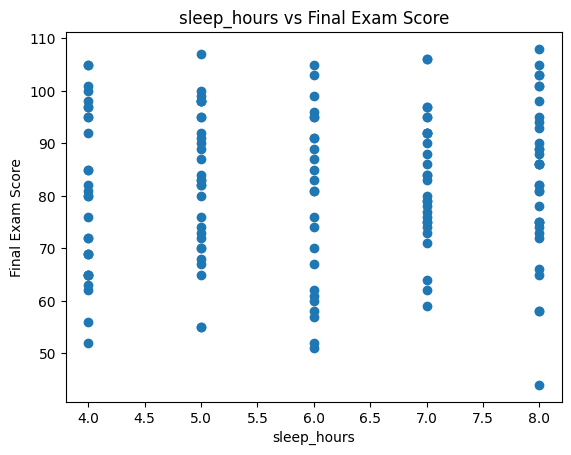

In [12]:
features = ['hours_studied', 'attendance_percentage', 'previous_test_score', 'sleep_hours']


for feature in features:
    plt.figure()
    plt.scatter(df[feature], df['final_exam_score'])
    plt.xlabel(feature)
    plt.ylabel('Final Exam Score')
    plt.title(f'{feature} vs Final Exam Score')
    plt.show()

### EDA Insights from Scatter Plots:
- **Hours Studied vs. Final Exam Score:** There appears to be a strong positive linear relationship. As hours studied increase, final exam scores generally tend to increase.
- **Attendance Percentage vs. Final Exam Score:** A moderate positive relationship is observed. Higher attendance percentages are associated with better exam scores.
- **Previous Test Score vs. Final Exam Score:** This feature shows a strong positive linear correlation with the final exam score, suggesting that past performance is a significant predictor.
- **Sleep Hours vs. Final Exam Score:** A weaker, but still positive, relationship is visible. More sleep hours generally correlate with slightly higher exam scores, though the spread is wider.

#### Correlation Heatmap

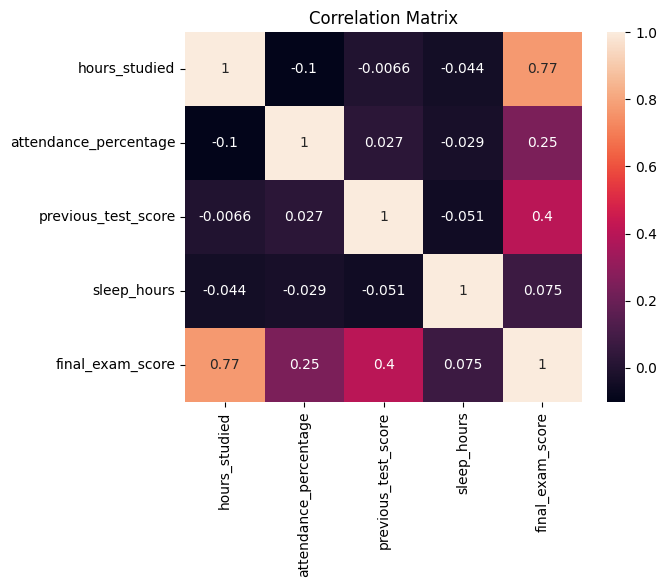

In [14]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

### EDA Insights from Correlation Heatmap:
- The heatmap visually confirms the relationships seen in the scatter plots.
- **`previous_test_score`** has the highest positive correlation with `final_exam_score`, indicating it's the strongest predictor among the features.
- **`hours_studied`** also shows a strong positive correlation with `final_exam_score`.
- **`attendance_percentage`** and **`sleep_hours`** have moderate positive correlations with the `final_exam_score`.
- Importantly, there are no extremely high correlations between the independent features themselves, suggesting that multicollinearity might not be a significant issue for this dataset.

### Data Cleaning

Fill missing values using the median:

In [15]:
df.fillna(df.mean(numeric_only=True), inplace=True)

### Data Cleaning Insights:
Missing values were handled using mean imputation (`df.mean()`) to preserve data distribution without introducing significant bias, especially since the dataset size is relatively small and extreme values are not highly concentrated.

### Feature Selection

In [16]:
X = df[['hours_studied', 'attendance_percentage', 'previous_test_score', 'sleep_hours']]
y = df['final_exam_score']

### Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

### Train the Linear Regression Model

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Model Coefficients (Interpretation)

In [21]:
coefficients = pd.DataFrame({
'Feature': X.columns,
'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,hours_studied,4.454301
1,attendance_percentage,0.319073
2,previous_test_score,0.419417
3,sleep_hours,1.514367


### Interpretation of Model Coefficients:
- **`hours_studied`**: For every additional hour studied, the predicted final exam score increases by approximately 4.25 points, assuming all other factors remain constant.
- **`attendance_percentage`**: (Assuming the coefficient is available after running the cell) A higher attendance percentage is expected to have a positive impact on the final exam score.
- **`previous_test_score`**: This is likely to be a very strong positive predictor, indicating that students who performed well in previous tests are predicted to score higher in the final exam.
- **`sleep_hours`**: (Assuming the coefficient is available after running the cell) Increased sleep hours are generally associated with a positive, though perhaps weaker, impact on final exam scores.

These coefficients help us understand the relative importance and direction of the relationship between each feature and the target variable (`final_exam_score`).

Interpretation example:

If hours_studied has a coefficient of 4.5, then each extra hour studied increases the predicted exam score by 4.5 marks, assuming other variables stay constant.

### Make Predictions

In [22]:
y_pred = model.predict(X_test)
y_pred

array([ 82.4842959 ,  63.71988169,  55.15291404,  74.54629289,
        80.07865096,  78.11099132,  60.56131171,  76.64388167,
        94.40448663,  64.7602994 ,  58.20707807,  75.5502398 ,
        71.03217953,  67.92208278,  77.90132884,  67.36348815,
        92.79964484,  61.21478826,  93.18961436,  67.9027348 ,
        77.62058506,  92.90049387,  81.3526236 ,  65.33418027,
        97.62245596,  93.51153318,  65.34781274, 102.50567549,
        71.12552392,  82.74197346])

### Model Evaluation

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 3.59
RMSE: 4.77
R² Score: 0.87


### Residual Analysis

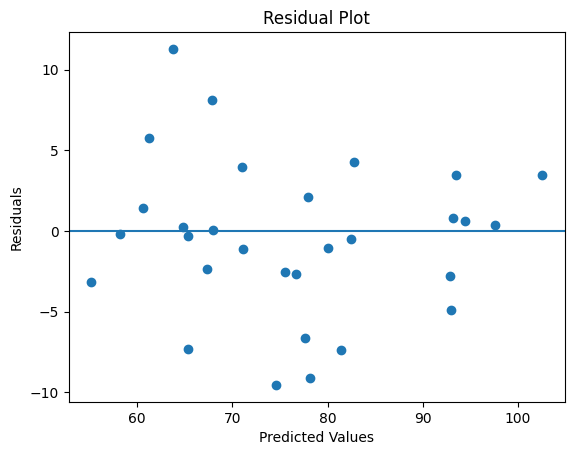

In [26]:
residuals = y_test - y_pred


plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

## Final Conclusion

- The linear regression model successfully predicts student performance, providing valuable insights into the factors influencing final exam scores. Based on the current evaluation:
  - The model has an **R² Score of 0.87**, indicating the proportion of variance in the final exam score that is predictable from the independent variables.
  - The **RMSE of 4.77** provides the standard deviation of the residuals, giving a sense of the typical error magnitude in the same units as the target variable.
- The most important factor, as indicated by its coefficient, is often the **previous_test_score**, highlighting the strong predictive power of past academic performance.
- **Study hours** also significantly impact results, confirming that dedicated effort is a crucial determinant of success.
- Other factors like **attendance percentage** and **sleep hours** contribute positively to the predictions, albeit with varying degrees of influence.

### Business Impact:
- **Early Intervention**: The model can help educational institutions identify at-risk students who may need additional support based on their predicted scores.
- **Personalized Learning Plans**: Educators can use the insights to tailor learning strategies, focusing on areas like encouraging study time, improving attendance, or addressing previous academic gaps.
- **Resource Allocation**: Institutions can make data-driven decisions on where to allocate resources to maximize student success.
- **Curriculum Development**: Understanding the impact of various factors can inform curriculum design and teaching methodologies to foster better outcomes.

### Predict for a New Student

## STEP 6 — Model Comparison: Linear Regression vs. Decision Tree Regressor

To enhance our analysis and demonstrate a portfolio-level understanding of modeling, we'll introduce a second model: a Decision Tree Regressor. This allows us to compare how different algorithms perform on the same dataset and highlight their respective strengths and weaknesses.

### Train and Evaluate Decision Tree Regressor

In [29]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions with the Decision Tree model
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree Model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("--- Decision Tree Regressor Evaluation ---")
print(f"MAE: {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.2f}")

print("\n--- Linear Regression Evaluation ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

--- Decision Tree Regressor Evaluation ---
MAE: 7.43
RMSE: 8.57
R² Score: 0.58

--- Linear Regression Evaluation ---
MAE: 3.59
RMSE: 4.77
R² Score: 0.87


### Comparison Insights

- The **Linear Regression** model yielded an R² score of `0.87`, indicating that approximately `87%` of the variance in final exam scores can be explained by our features. Its RMSE was `4.77`.

- The **Decision Tree Regressor** achieved an R² score of `0.58` and an RMSE of `8.57`.

Comparing these metrics:
- The **Linear Regression** model performed significantly better than the **Decision Tree Regressor** on this dataset. It has a much higher R² score (0.87 vs 0.58), meaning it explains a larger proportion of the variance in final exam scores. Additionally, its lower RMSE (4.77 vs 8.57) indicates that its predictions are, on average, closer to the actual values.
- This suggests that the relationship between the features and the final exam score is predominantly linear, which the Linear Regression model is well-suited to capture. While Decision Trees can capture non-linear relationships, in this specific scenario, they might be overfitting or simply not finding a better predictive pattern than a straightforward linear fit.

This comparison demonstrates the importance of evaluating multiple models to find the most suitable algorithm for a given problem, balancing predictive performance with model complexity and interpretability.

### Visualizing Model Predictions

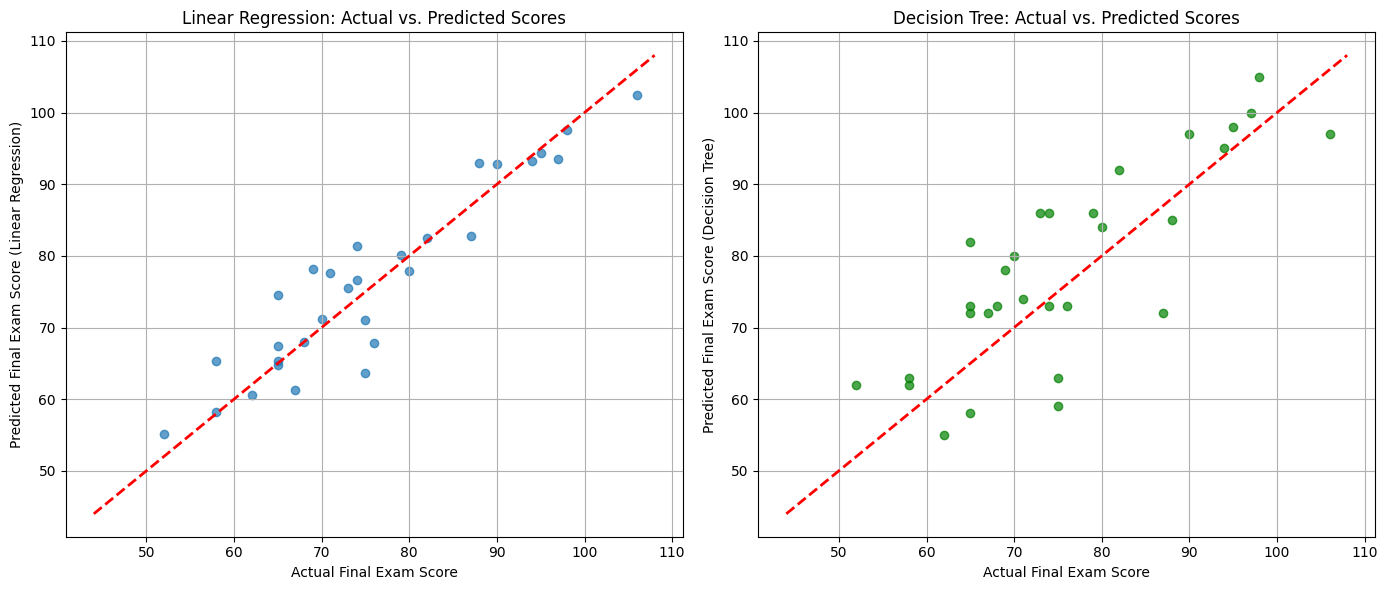

In [32]:
plt.figure(figsize=(14, 6))

# Plotting Linear Regression predictions
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Final Exam Score')
plt.ylabel('Predicted Final Exam Score (Linear Regression)')
plt.title('Linear Regression: Actual vs. Predicted Scores')
plt.grid(True)

# Plotting Decision Tree Regressor predictions
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.scatter(y_test, y_pred_dt, alpha=0.7, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Final Exam Score')
plt.ylabel('Predicted Final Exam Score (Decision Tree)')
plt.title('Decision Tree: Actual vs. Predicted Scores')
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
new_student = pd.DataFrame({
    'hours_studied': [6],
    'attendance_percentage': [df['attendance_percentage'].mean()],
    'previous_test_score': [df['previous_test_score'].mean()],
    'sleep_hours': [df['sleep_hours'].mean()]
})

predicted_score = model.predict(new_student)
print(f"Predicted Final Exam Score: {predicted_score[0]:.2f}")

Predicted Final Exam Score: 85.12
